In [3]:
import pandas as pd

train_df = pd.read_csv("KDDTrain+.txt", header=None)
test_df  = pd.read_csv("KDDTest+.txt", header=None)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (125973, 43)
Test shape : (22544, 43)


In [6]:
# Auto-generate column names by index
train_df.columns = [f"col_{i}" for i in range(train_df.shape[1])]

train_df.head()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_33,col_34,col_35,col_36,col_37,col_38,col_39,col_40,col_41,col_42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [7]:
print("Second last column (label):")
print(train_df.iloc[:, -2].head())

print("\nLast column (difficulty):")
print(train_df.iloc[:, -1].head())

Second last column (label):
0     normal
1     normal
2    neptune
3     normal
4     normal
Name: col_41, dtype: object

Last column (difficulty):
0    20
1    15
2    19
3    21
4    21
Name: col_42, dtype: int64


In [10]:
rename_map = {
    0: "duration",
    1: "protocol_type",
    2: "service",
    3: "flag",
    4: "src_bytes",
    5: "dst_bytes",
    6: "land",
    7: "wrong_fragment",
    8: "urgent",
    9: "hot",
    10: "num_failed_logins",
    11: "logged_in",
    12: "num_compromised",
    13: "root_shell",
    14: "su_attempted",
    15: "num_root",
    16: "num_file_creations",
    17: "num_shells",
    18: "num_access_files",
    19: "num_outbound_cmds",
    20: "is_host_login",
    21: "is_guest_login",
    22: "count",
    23: "srv_count",
    24: "same_srv_rate",
    25: "diff_srv_rate",
    26: "srv_diff_host_rate",
    27: "dst_host_count",
    28: "dst_host_srv_count",
    29: "dst_host_same_srv_rate",
    30: "dst_host_diff_srv_rate",
    31: "dst_host_same_src_port_rate",
    32: "dst_host_srv_diff_host_rate",
    33: "dst_host_serror_rate",
    34: "dst_host_srv_serror_rate",
    35: "dst_host_rerror_rate",
    36: "dst_host_srv_rerror_rate",
    41: "label",
    42: "difficulty"
}

train_df = train_df.rename(columns={f"col_{k}": v for k, v in rename_map.items()})
test_df  = test_df.rename(columns={f"col_{k}": v for k, v in rename_map.items()})


In [11]:
print(train_df[["label", "difficulty"]].head())
print(train_df.shape)

     label  difficulty
0   normal          20
1   normal          15
2  neptune          19
3   normal          21
4   normal          21
(125973, 43)


In [12]:
train_df_normal = train_df[train_df["label"] == "normal"]

print("Original train size:", train_df.shape)
print("Normal-only train size:", train_df_normal.shape)
print("Unique labels in training:", train_df_normal["label"].unique())

Original train size: (125973, 43)
Normal-only train size: (67343, 43)
Unique labels in training: ['normal']


In [15]:
print(test_df.columns.tolist())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]


In [16]:
# Access by position (this NEVER fails)
print(test_df.iloc[:, -2].head())  # label
print(test_df.iloc[:, -1].head())  # difficulty

0    neptune
1    neptune
2     normal
3      saint
4      mscan
Name: 41, dtype: object
0    21
1    21
2    21
3    15
4    11
Name: 42, dtype: int64


In [17]:
# Get actual column names by position
label_col = test_df.columns[-2]
difficulty_col = test_df.columns[-1]

print("Label column name:", label_col)
print("Difficulty column name:", difficulty_col)

# Rename safely
test_df = test_df.rename(columns={
    label_col: "label",
    difficulty_col: "difficulty"
})

print(test_df[["label", "difficulty"]].head())

Label column name: 41
Difficulty column name: 42
     label  difficulty
0  neptune          21
1  neptune          21
2   normal          21
3    saint          15
4    mscan          11


In [20]:
# Rename categorical columns by index (SAFE)
X_train = X_train.rename(columns={
    X_train.columns[1]: "protocol_type",
    X_train.columns[2]: "service",
    X_train.columns[3]: "flag"
})

X_test = X_test.rename(columns={
    X_test.columns[1]: "protocol_type",
    X_test.columns[2]: "service",
    X_test.columns[3]: "flag"
})

print(X_train[["protocol_type", "service", "flag"]].head())

   protocol_type   service flag
0            tcp  ftp_data   SF
1            udp     other   SF
3            tcp      http   SF
4            tcp      http   SF
12           tcp      http   SF


In [21]:
categorical_cols = ["protocol_type", "service", "flag"]

X_train_enc = pd.get_dummies(X_train, columns=categorical_cols)
X_test_enc  = pd.get_dummies(X_test,  columns=categorical_cols)

In [22]:
print("Encoded train shape:", X_train_enc.shape)
print("Encoded test shape :", X_test_enc.shape)

print("NaNs in train:", X_train_enc.isna().any().any())
print("NaNs in test :", X_test_enc.isna().any().any())

Encoded train shape: (67343, 77)
Encoded test shape : (22544, 116)
NaNs in train: False
NaNs in test : False


In [23]:
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc,
    join="left",
    axis=1,
    fill_value=0
)

print("Aligned train shape:", X_train_enc.shape)
print("Aligned test shape :", X_test_enc.shape)

Aligned train shape: (67343, 77)
Aligned test shape : (22544, 77)


#SCALING

##create and fit scaler


In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

print("Train scaled min/max:", X_train_scaled.min(), X_train_scaled.max())
print("Test scaled min/max :", X_test_scaled.min(), X_test_scaled.max())

Train scaled min/max: 0.0 1.0
Test scaled min/max : 0.0 1.0


##define model dimension

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_train_scaled.shape[1]
print("Input dimension:", input_dim)

Input dimension: 77


In [26]:
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)

# Decoder
decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(input_dim, activation="sigmoid")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

In [27]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 77)             │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,189 (55.43 KB)

 Trainable params: 14,189 (55.43 KB)

 Non-trainable params: 0 (0.00 B)

## traing model

In [28]:
history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0951 - val_loss: 0.0089
Epoch 2/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065 - val_loss: 0.0034
Epoch 3/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0030 - val_loss: 0.0025
Epoch 4/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 5/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 6/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 7/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 8/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 9/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 10/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 11/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.0205e-04 - val_loss: 8.6298e-04
Epoch 12/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [29]:
print("Final training loss:", history.history["loss"][-1])
print("Final validation loss:", history.history["val_loss"][-1])

Final training loss: 0.0007037362665869296
Final validation loss: 0.0007259485428221524


## reconstruction error and threshold


In [30]:
# Reconstruct training data
X_train_recon = autoencoder.predict(X_train_scaled, verbose=0)

# Reconstruction error (MSE per sample)
train_recon_error = (
    (X_train_scaled - X_train_recon) ** 2
).mean(axis=1)

print("Train reconstruction error stats:")
print("Min :", train_recon_error.min())
print("Mean:", train_recon_error.mean())
print("Max :", train_recon_error.max())

Train reconstruction error stats:
Min : 4.193825339526689e-06
Mean: 0.0007012383944847968
Max : 0.053324387067313656


In [32]:
import numpy as np
error_threshold = np.percentile(train_recon_error, 95)
print("Reconstruction error threshold:", error_threshold)

Reconstruction error threshold: 0.0016173660348010152


## baseline evaluation

In [33]:
# Reconstruct test data
X_test_recon = autoencoder.predict(X_test_scaled, verbose=0)

# Reconstruction error per test sample
test_recon_error = (
    (X_test_scaled - X_test_recon) ** 2
).mean(axis=1)

print("Test reconstruction error stats:")
print("Min :", test_recon_error.min())
print("Mean:", test_recon_error.mean())
print("Max :", test_recon_error.max())

Test reconstruction error stats:
Min : 0.000962290918215186
Mean: 0.02040675579973935
Max : 0.0691036643870057


In [35]:
# 0 = normal, 1 = attack
y_true = (y_test != "normal").astype(int)
y_pred = (test_recon_error > error_threshold).astype(int)

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

far = fp / (fp + tn)
recall = tp / (tp + fn)

print("Confusion Matrix:")
print(cm)

print("False Alarm Rate (FAR):", far)
print("Recall (Detection Rate):", recall)

Confusion Matrix:
[[   32  9679]
 [  257 12576]]
False Alarm Rate (FAR): 0.9967047677891051
Recall (Detection Rate): 0.9799735058053456


## save model

In [37]:
import joblib

# Save trained autoencoder
autoencoder.save("autoencoder.h5")

# Save scaler (fitted only on normal data)
joblib.dump(scaler, "scaler.pkl")

# Save reconstruction error threshold
joblib.dump(error_threshold, "threshold.pkl")

print("Model, scaler, and threshold saved")

Model, scaler, and threshold saved


In [38]:
import os

print(os.path.exists("autoencoder.h5"))
print(os.path.exists("scaler.pkl"))
print(os.path.exists("threshold.pkl"))

True
True
True


#MC dropout

In [39]:
from tensorflow.keras.layers import Dropout

input_dim = X_train_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
x = Dense(64, activation="relu")(input_layer)
x = Dropout(0.2)(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.2)(x)

# Decoder
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)
output_layer = Dense(input_dim, activation="sigmoid")(x)

mc_autoencoder = Model(input_layer, output_layer)
mc_autoencoder.compile(optimizer="adam", loss="mse")

mc_autoencoder.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 77)             │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,189 (55.43 KB)

 Trainable params: 14,189 (55.43 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
mc_autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1020 - val_loss: 0.0101
Epoch 2/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0107 - val_loss: 0.0059
Epoch 3/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0072 - val_loss: 0.0049
Epoch 4/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0062 - val_loss: 0.0040
Epoch 5/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0053 - val_loss: 0.0033
Epoch 6/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0047 - val_loss: 0.0029
Epoch 7/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0043 - val_loss: 0.0026
Epoch 8/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040 - val_loss: 0.0024
Epoch 9/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0037 - val_loss: 0.0022
Epoch 10/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0035 - val_loss: 0.0020
Epoch 11/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0033 - val_loss: 0.0018
Epoch 12/20
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [41]:
import numpy as np

def mc_dropout_predict(model, X, T=20):
    preds = []
    for _ in range(T):
        preds.append(model(X, training=True).numpy())
    return np.array(preds)

##uncertinity aware recontrsuction

In [42]:
# Multiple stochastic reconstructions
mc_recons = mc_dropout_predict(mc_autoencoder, X_test_scaled, T=20)

# Mean & variance of reconstruction
mean_recon = mc_recons.mean(axis=0)
var_recon  = mc_recons.var(axis=0)

# Error + uncertainty
recon_error = ((X_test_scaled - mean_recon) ** 2).mean(axis=1)
uncertainty = var_recon.mean(axis=1)

In [43]:
# Thresholds
error_th = error_threshold
uncert_th = np.percentile(uncertainty, 95)

y_pred_mc = ((recon_error > error_th) & (uncertainty > uncert_th)).astype(int)

In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_mc)
tn, fp, fn, tp = cm.ravel()

far_mc = fp / (fp + tn)
recall_mc = tp / (tp + fn)

print("MC Dropout Confusion Matrix:")
print(cm)
print("MC FAR:", far_mc)
print("MC Recall:", recall_mc)

MC Dropout Confusion Matrix:
[[ 9706     5]
 [11710  1123]]
MC FAR: 0.0005148800329523221
MC Recall: 0.08750876646146653


## FAR vs RECALL smoothing


In [45]:
# Normalize reconstruction error
err_min, err_max = recon_error.min(), recon_error.max()
error_norm = (recon_error - err_min) / (err_max - err_min + 1e-8)

# Normalize uncertainty
unc_min, unc_max = uncertainty.min(), uncertainty.max()
uncert_norm = (uncertainty - unc_min) / (unc_max - unc_min + 1e-8)

In [47]:
alpha = 0.5   # importance of uncertainty (tunable)
final_score = error_norm + alpha * uncert_norm

In [48]:
# Use normal samples only to set threshold
normal_scores = final_score[y_true == 0]

fusion_threshold = np.percentile(normal_scores, 95)
print("Fusion threshold:", fusion_threshold)

Fusion threshold: 0.5655842171087344


In [49]:
y_pred_fused = (final_score > fusion_threshold).astype(int)

In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_fused)
tn, fp, fn, tp = cm.ravel()

far_fused = fp / (fp + tn)
recall_fused = tp / (tp + fn)

print("FUSED Confusion Matrix:")
print(cm)

print("FUSED FAR:", far_fused)
print("FUSED Recall:", recall_fused)

FUSED Confusion Matrix:
[[9225  486]
 [5343 7490]]
FUSED FAR: 0.05004633920296571
FUSED Recall: 0.5836515234161926


In [51]:
import joblib

# Save MC Dropout autoencoder
mc_autoencoder.save("mc_autoencoder.h5")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save baseline reconstruction-error threshold
joblib.dump(error_threshold, "error_threshold.pkl")

# Save fusion parameters
fusion_params = {
    "alpha": 0.5,
    "fusion_threshold": fusion_threshold
}
joblib.dump(fusion_params, "fusion_params.pkl")

print(" Final fused IDS artifacts saved")

 Final fused IDS artifacts saved


In [63]:
import os
import joblib

# Create artifacts directory
os.makedirs("artifacts", exist_ok=True)

# Save MC Dropout autoencoder
mc_autoencoder.save("artifacts/mc_autoencoder.h5")

# Save scaler
joblib.dump(scaler, "artifacts/scaler.pkl")

# Save baseline threshold
joblib.dump(error_threshold, "artifacts/error_threshold.pkl")

# Save fusion parameters
joblib.dump(
    {
        "alpha": alpha,
        "fusion_threshold": fusion_threshold
    },
    "artifacts/fusion_params.pkl"
)

# Save training feature columns
joblib.dump(X_train_enc.columns.tolist(), "artifacts/train_columns.pkl")

print("All artifacts saved to /artifacts")

All artifacts saved to /artifacts


In [64]:
import os
os.listdir("artifacts")

['fusion_params.pkl',
 'train_columns.pkl',
 'scaler.pkl',
 'mc_autoencoder.h5',
 'error_threshold.pkl']

In [52]:
import os

print(os.path.exists("mc_autoencoder.h5"))
print(os.path.exists("scaler.pkl"))
print(os.path.exists("error_threshold.pkl"))
print(os.path.exists("fusion_params.pkl"))

True
True
True
True


# REAL TIME FUSED IDS

In [66]:
import pandas as pd
import numpy as np
import joblib
import time

from tensorflow.keras.models import load_model
from tensorflow.keras.losses import MeanSquaredError

In [93]:
import os

os.listdir(".")

['.config',
 'flow_input.csv',
 'fusion_params.pkl',
 'KDDTest+.txt',
 'artifacts',
 'streamlit_ui.py',
 'scaler.pkl',
 'mc_autoencoder.h5',
 'error_threshold.pkl',
 'autoencoder.h5',
 '.ipynb_checkpoints',
 'KDDTrain+.txt',
 'threshold.pkl',
 'realtime_ids.py',
 'sample_data']

In [92]:
!python realtime_ids.py

2026-02-11 03:20:53.933414: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770780053.971467   16028 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770780053.982675   16028 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770780054.009397   16028 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770780054.009459   16028 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770780054.009469   16028 computation_placer.cc:177] computation placer alr

In [102]:
!pip install gradio

In [131]:
!python gradio_ui.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a51d7fbfced6adb559.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Keyboard interruption in main thread... closing server.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 3043, in block_thread
    time.sleep(0.1)
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/content/gradio_ui.py", line 38, in <module>
    demo.launch(share=True)
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2950, in launch
    self.block_thread()
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 3047, in block_thread
    self.server.close()
  File "/usr/local/lib/python3.12/dist-pa

#EVALUATION

In [117]:
print(X_test_scaled.shape)
print(len(y_test))

(22544, 77)
22544


In [118]:
final_score, alerts = fused_anomaly_detection(
    X_test_scaled,
    mc_autoencoder,
    alpha,
    fusion_threshold
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(22544, 77))
  warnings.warn(msg)


In [119]:
print("Test labels:", len(y_test))
print("Predictions:", len(alerts))


Test labels: 22544
Predictions: 22544


In [121]:
y_true = (y_test != "normal").astype(int)
y_pred = alerts
y_score = final_score
print(len(y_true), len(y_pred))

22544 22544


In [122]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score


In [123]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[9424  287]
 [5455 7378]]


In [124]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall (Detection Rate):", recall)
print("F1-Score:", f1)

Accuracy: 0.7452980837473385
Precision: 0.9625570776255707
Recall (Detection Rate): 0.5749240240006234
F1-Score: 0.7198751097668065


In [125]:
far = fp / (fp + tn)
dr = tp / (tp + fn)

print("False Alarm Rate (FAR):", far)
print("Detection Rate (DR):", dr)


False Alarm Rate (FAR): 0.05004633920296571
Detection Rate (DR): 0.5836515234161926


In [126]:
roc_auc = roc_auc_score(y_true, y_score)
pr_auc = average_precision_score(y_true, y_score)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.7082995379367965
PR-AUC: 0.8272751830987525


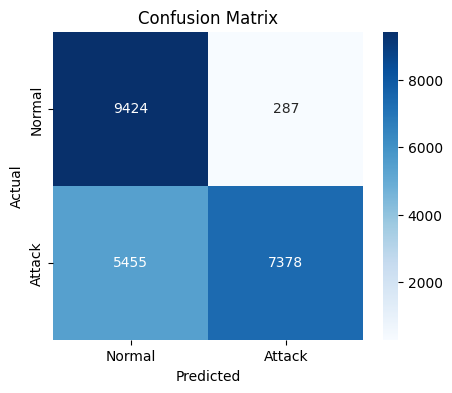

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

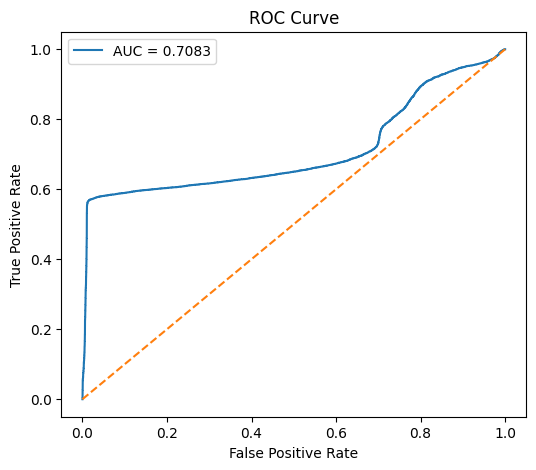

In [128]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

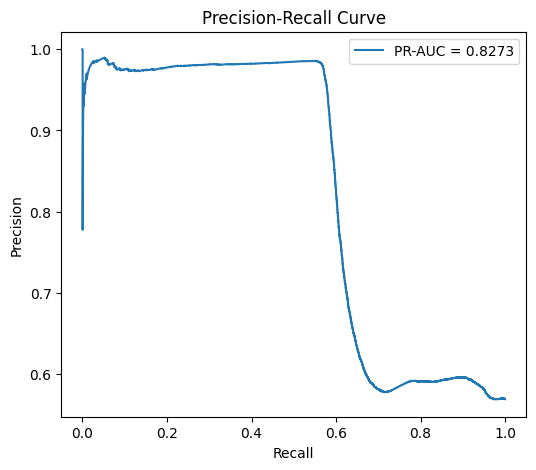

In [129]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
pr_auc = average_precision_score(y_true, y_score)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

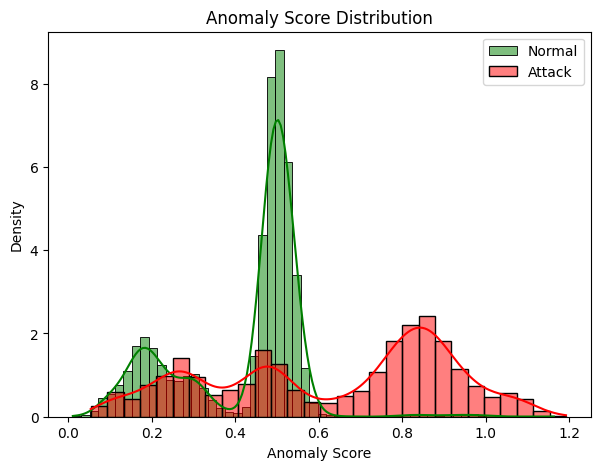

In [130]:
plt.figure(figsize=(7,5))

sns.histplot(y_score[y_true==0], color="green", label="Normal", kde=True, stat="density")
sns.histplot(y_score[y_true==1], color="red", label="Attack", kde=True, stat="density")

plt.legend()
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Density")
plt.show()